# Диффузионные модели (Diffusion Models)

**темы:** развитие идеи латентных моделей, forward и reverse процессы, DDPM, параметризация и noise-prediction loss, U-Net, диффузия на непрерывном времени (SDE, уравнение Фоккера–Планка), DDIM, Stable Diffusion, CLIP, DALL·E

**Автор:** Федоров Артем Максимович

In [43]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

# Позиционирование диффузионных моделей

На предыдущих лекциях мы познакомились с двумя ключевыми классическими типами архитектур:

- **GAN** — неявная генеративная модель, обучение которой осуществляется через состязетельный процесс "игры" генератора и дискриминатора. Даёт визуально чёткие сэмплы, но страдает от mode collapse и не позволяет оценить плотность настоящего распределения через $p_\theta(x) \approx p^\ast(x) $.

- **VAE** — простейшая латентная модель, вводящая латентное пространство $\mathcal{Z}$ и обучаемая через некоторый функционал, приближающий оригинальную задачу максимизации вероятности пронаблюдать выборку $\log p^\ast(x) \approx \log p_\theta(x) \to \max$ (имеется в виду вариационная нижняя оценка ELBO). Даёт нормированную плотность $p_\theta(x)$, но генерирует размытые объекты из-за ограниченной возможности как энкодера, так и декодера запомнить правила отображения сложных объектов в "простое" пространство. 

Оба подхода занимают свои ниши в фундаментальном трейдоффе генеративного моделирования: **качество сэмплов**, **скорость генерации** и **покрытие мод** распределения $p^*$.

<p align="center">
  <img src="images/lecture_4/gan_diff_vae.png" style="width:70%;">
</p>

## Развитие латентных моделей

Естественный вопрос: возможно ли совместить **высокое качество** генерации (как у GAN) с **хорошим покрытием мод** (как у VAE). Отдельно, конечно, хотелось бы еще и распределение оригинальных данных оценивать, так как это много где может быть использовано? 

Ответ — **да**, но за это придётся заплатить **скоростью инференса**. Именно такой компромисс реализуют **диффузионные модели** (Diffusion Models), которые за последние годы стали стандартом де-факто в генерации изображений, аудио, видео и 3D-контента.

> Ключевая идея, которую мы будем развивать на протяжении лекции: **диффузионная модель — это обобщение VAE**, в котором вместо одного «сложного» шага декодирования $z \to x$ используется **длинная цепочка простых шагов** $z_T \to z_{T-1} \to \cdots \to z_0 \approx x$. Каждый отдельный шаг — элементарный и хорошо обусловленный, а сложность моделируемого распределения возникает из композиции.

# Диффузия как обобщение VAE

При выводе VAE мы вводили латентную переменную $z \in \mathcal{Z}$ и строили генеративную модель в виде:

$$p_\theta(x, z) = p_\theta(x \mid z) \, p(z), \quad p(z) = \mathcal{N}(0, I)$$

Обучение сводилось к максимизации ELBO:

$$\log p^\ast(x) \approx \log p_\theta(x) \geq\mathcal{L}_{\text{ELBO}}(x; \theta, \phi) = \mathbb{E}_{q_\phi(z|x)}\left[\log p_\theta(x \mid z)\right] - \text{KL}\left(q_\phi(z \mid x) \,\|\, p(z)\right)$$

$$\mathcal{L}_{\text{ELBO}}(x; \theta, \phi) \to \max \Longrightarrow \log p_\theta(x) \to \max$$

Такая модель обладает простой интерпретацией: **энкодер** $q_\phi(z \mid x)$ кодирует объект в латент, **декодер** $p_\theta(x \mid z)$ восстанавливает объект из латента

- $\mathbb{E}_{q_\phi(z|x)}\left[\log p_\theta(x \mid z)\right]$ – отвечает за качество реконструкции – насколько хорошо модель способна выучить латентное пространство / отображать в него реальные объекты.
- $\text{KL}\left(q_\phi(z \mid x) \,\|\, p(z)\right)$ – отвечает за интерпретабильно латентного пространства – насколько распределение точек в латентном пространстве сильно отличается от того, каким мы его моделируем, тем самым позволяя оценивать плотность $p^\ast$ и семплировать из распределения.



## В чём проблема VAE

Вся сложность распределения данных $p^*$ должна быть «захвачена» единственным шагом декодера $p_\theta(x \mid z)$. При простом прайоре $p(z) = \mathcal{N}(0, I)$ это означает, что нейросетевой декодер должен научиться превращать Гауссовский шум в сложное многомодальное распределение реальных объектов — **за один шаг**.

На практике это приводит к двум сценариям:
1. Декодер недостаточно мощный — как мы уже разбирали на предыдущей лекции, генерируемые объекты становятся размытыми, усреднениями некоторых "множеств" объектов обучающей выборки, моды не покрываются и вообще все плохо.
2. Декодер избыточно мощный — перепараметризация ведет к плохой генерализации (обобщающей способности) $\Rightarrow$ не получится хорошо работать с новыми/генерируемыми данными, оптимизация ELBO становится плохо обусловленной, обучение нестабильно. 

> Да, стоит отметить, что сейчас начали появляться новые подходы, что выучивают сложное отображение между двумя распределениями за один шаг, при чем достаточно хорошо, но они все еще не способны состязаться с диффузионками, о которых далее пойдет речь. К примеру такие статьи:
> 
> 1) [Generative Modeling via Drifting](https://arxiv.org/abs/2602.04770)
> 2) [One Step Diffusion via Shortcut Models](https://arxiv.org/abs/2410.12557)
> 3) [On the Design of One-step Diffusion via Shortcutting Flow Paths](https://arxiv.org/abs/2512.11831)
> 4) [SANA-Sprint: One-Step Diffusion with Continuous-Time Consistency Distillation](https://arxiv.org/abs/2503.09641)



Интуитивно, мы пытаемся вобрать всю сложность данных одним простое распределение $p(z)$ через слишком сложны единственный шаг декодера $p_\theta(x \mid z)$, что сделать нельзя либо из-за простоты декодера, либо из-за излишней сложности последнего мы просто не можем это выучить.

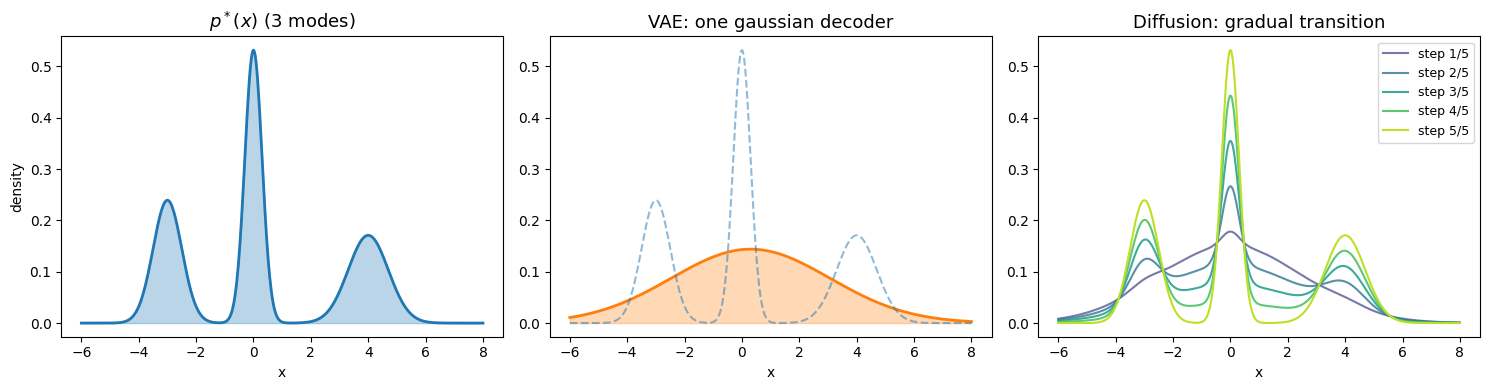

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# real distribution: gaussian mixture
means = [-3, 0, 4]
stds  = [0.5, 0.3, 0.7]
weights = [0.3, 0.4, 0.3]

x_grid = np.linspace(-6, 8, 500)
p_true = sum(w * norm.pdf(x_grid, m, s) for w, m, s in zip(weights, means, stds))

axes[0].fill_between(x_grid, p_true, alpha=0.3, color='C0')
axes[0].plot(x_grid, p_true, 'C0', lw=2)
axes[0].set_title(r'$p^*(x)$ (3 modes)', fontsize=13)
axes[0].set_xlabel('x')
axes[0].set_ylabel('density')

# best approximation with one gaussian
mu_fit = sum(w * m for w, m in zip(weights, means))
var_fit = sum(w * (s**2 + m**2) for w, m, s in zip(weights, means, stds)) - mu_fit**2
p_gauss = norm.pdf(x_grid, mu_fit, np.sqrt(var_fit))

axes[1].fill_between(x_grid, p_gauss, alpha=0.3, color='C1')
axes[1].plot(x_grid, p_gauss, 'C1', lw=2)
axes[1].plot(x_grid, p_true, 'C0--', lw=1.5, alpha=0.5)
axes[1].set_title('VAE: one gaussian decoder', fontsize=13)
axes[1].set_xlabel('x')

# approximation via chain of simple steps
T = 5
alphas = np.linspace(0.05, 1.0, T)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, T))
for i, alpha in enumerate(alphas):
    p_interp = alpha * p_true + (1 - alpha) * norm.pdf(x_grid, 0, 2.5)
    axes[2].plot(x_grid, p_interp, color=colors[i], lw=1.5,
                 label=f'step {i+1}/{T}', alpha=0.7 + 0.3*alpha)

axes[2].set_title('Diffusion: gradual transition', fontsize=13)
axes[2].set_xlabel('x')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

На правом графике видна ключевая идея: вместо одного «скачка» от простого распределения к сложному, мы выстраиваем **последовательность промежуточных распределений**, каждое из которых лишь немного изменяет предыдущее. Каждый отдельный переход — простой, а сложность возникает из их композиции.

## Определение диффузии

**Ключевая идея:** вместо одной латентной переменной $z$ введём **цепочку** латентных переменных:

$$z_T \to z_{T-1} \to \cdots \to z_1 \to z_0 \approx x$$

где $z_T$ — чистый шум (например из $\mathcal{N}(0,  I)$), $z_0$ — объект из носителя реальных данных $\mathcal{X}_\text{data}$.

Каждый переход $z_t \to z_{t-1}$ реализуется простым параметрическим распределением (как правило, гауссовым).
$$z_{t-1} \sim p_{\theta, t}(z_{t-1} \mid z_t) \quad\quad \text{e.g.} \,\,\,\, z_{t-1} \sim \mathcal{N}(z_{t-1} \mid f_\theta(z_t; t), \sigma^2_t I)$$

Формально мы по-прежнему находимся в рамках латентных моделей, только теперь латентное пространство $\mathcal{Z}$ явно (конструктивно) расширяется до $\mathcal{Z}^T = \mathcal{Z}_1 \times \cdots \times \mathcal{Z}_T$, и совместная генеративная модель записывается как:

$$p_\theta(x, z_{1:T}) = p(z_T) \prod_{t=1}^{T} p_\theta(z_{t-1} \mid z_t), \quad z_0 := x$$

<p align="center">
  <img src="images/lecture_4/diffusion_cat.png" style="width:90%;">
</p>

### Как определять цепочку $\{ z_t \}$

Заметим принципиальную особенность описываемого процесса: $z_t \to z_{t-1}$ — это **восстановление информации**, по зашумлённому наблюдению нужно «угадать», как нужно изменить $z_t$ чтобы приблизиться к заветному $z_0 = x$. В общем случае это невозможно аналитически — одному и тому же $z_t$ могут соответствовать совершенно разные $z_{t-1}$, и, забегая вперед, именно это мы будем обучать делать нашу нейронную сеть. 

Чтобы продвинуться дальше, нам нужно зайти с другого конца – а как в принципе соотносятся между собой $z_t$? Исходя из предыдущего замечания, становится очевидно, что нужно пробовать определять такую цепочку наоборот! Будем считать, что для любого $x$ мы можем определить некоторый стохастический (случайностный) процесс, что шаг за шагом "вымывает" из оригинального объекта "информацию" по маленьким кусочкам, в конце оставляя только гауссовский шум. Собственно поэтому его называют процессом зашумления.

Тогда мы можем явно задать "ядро" процесса $q(z_t \mid z_{t-1})$ – как зашумляется объект при $t-1 \to t$. Далее именно процесс зашумления $x =z_0 \to z_1 \to ... \to z_T$ мы будем считать "прямым" процессом, потому что его мы считать умеем. А вот для генерации объектов нам придется этот процесс обращать, получая "обратный" процесс:

- **Прямой процесс** $q(z_t \mid z_{t-1})$ мы задаём *руками*, без обучения — это просто добавление шума по расписанию
- **Обратный процесс** $p_\theta(z_{t-1} \mid z_t)$ мы *обучаем* нейросетью — она должна научиться восстанавливать информацию, опираясь на статистические закономерности обучающей выборки

<p align="center">
  <img src="images/lecture_4/process.png" style="width:90%;">
</p>

**Далее будем работать только с картинками, однако при желании все это можно перенести на другие носители пространства (даже дискретные) для других $\mathcal{X}$ при помощи изменения формата данных и самих распределений.**

### Forward (прямой) процесс

В отличие от VAE, где приближённый апостериор $q_\phi(z \mid x)$ параметризуется обучаемой нейросетью, в диффузионной модели «энкодер» задаётся **явно и без обучаемых параметров**. Это фиксированный марковский процесс постепенного зашумления:

$$q(z_{1:T} \mid x) = \prod_{t=1}^{T} q(z_t \mid z_{t-1}), \quad q(z_t \mid z_{t-1}) = \mathcal{N}\!\left(z_t;\, \sqrt{\alpha_t}\, z_{t-1},\, (1 - \alpha_t)\, I\right)$$

где $\alpha_t \in (0, 1)$ — заранее выбранные коэффициенты, определяемые **расписанием шума** (noise schedule). На каждом шаге мы:
1. Немного масштабируем сигнал: $\sqrt{\alpha_t}\, z_{t-1}$
2. Добавляем немного шума: $(1 - \alpha_t)\, I$

При $T$ достаточно большом и правильно подобранном расписании $\{\alpha_t\}$, конечное распределение $q(z_T \mid x)$ становится практически неотличимым от $\mathcal{N}(0, I)$, то есть вся информация об $x$ «стирается» шумом.

---

Выбор $\alpha_t$ может показаться неестественным – почему мы не можем, например, сделать сетку от 1 до 0 в $k$ шагов и постепенно убирать долю оригинального обекта и добавлять шум? На самом деле выбор расписания шума (noise schedule) вопрос исследований – для разных задач и разных данных в частности нужно выбирать свое расписание. Однако вид, как вводится такое расписание через домножающие элементы $\alpha_t$ является неким стандартом, так как это все еще очень гибкий способ задания эволюции процесса зашумления, вместе с тем формулы получаются очень простыми.


Поскольку ядро перехода гауссово, а гауссово распределение устойчиво относительно линейных преобразований, мы можем свернуть всю цепочку $q(z_1 \mid x), q(z_2 \mid z_1), \ldots, q(z_t \mid z_{t-1})$ в одно распределение. На первом шаге: $z_1 = \sqrt{\alpha_1}\, x + \sqrt{1-\alpha_1}\,\varepsilon_1$. На втором:
$$z_2 = \sqrt{\alpha_2}\, z_1 + \sqrt{1-\alpha_2}\,\varepsilon_2 = \sqrt{\alpha_2 \alpha_1}\, x + \sqrt{\alpha_2(1-\alpha_1)}\,\varepsilon_1 + \sqrt{1-\alpha_2}\,\varepsilon_2$$

Для произвольного шага $t$ формула принимает вид:

$$z_t = \sqrt{\bar\alpha_t}\, x + \sqrt{1 - \bar\alpha_t}\, \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$

Это ключевое свойство: чтобы зашумить объект до произвольного момента $t$, **не нужно последовательно проходить все промежуточные шаги** — достаточно одного семплирования. При обучении мы будем на каждой итерации выбирать случайный $t$, и свернутая форма позволит мгновенно получить пару $(z_t, \varepsilon)$, не тратя вычисления на цепочку.

### Примеры forward процессов

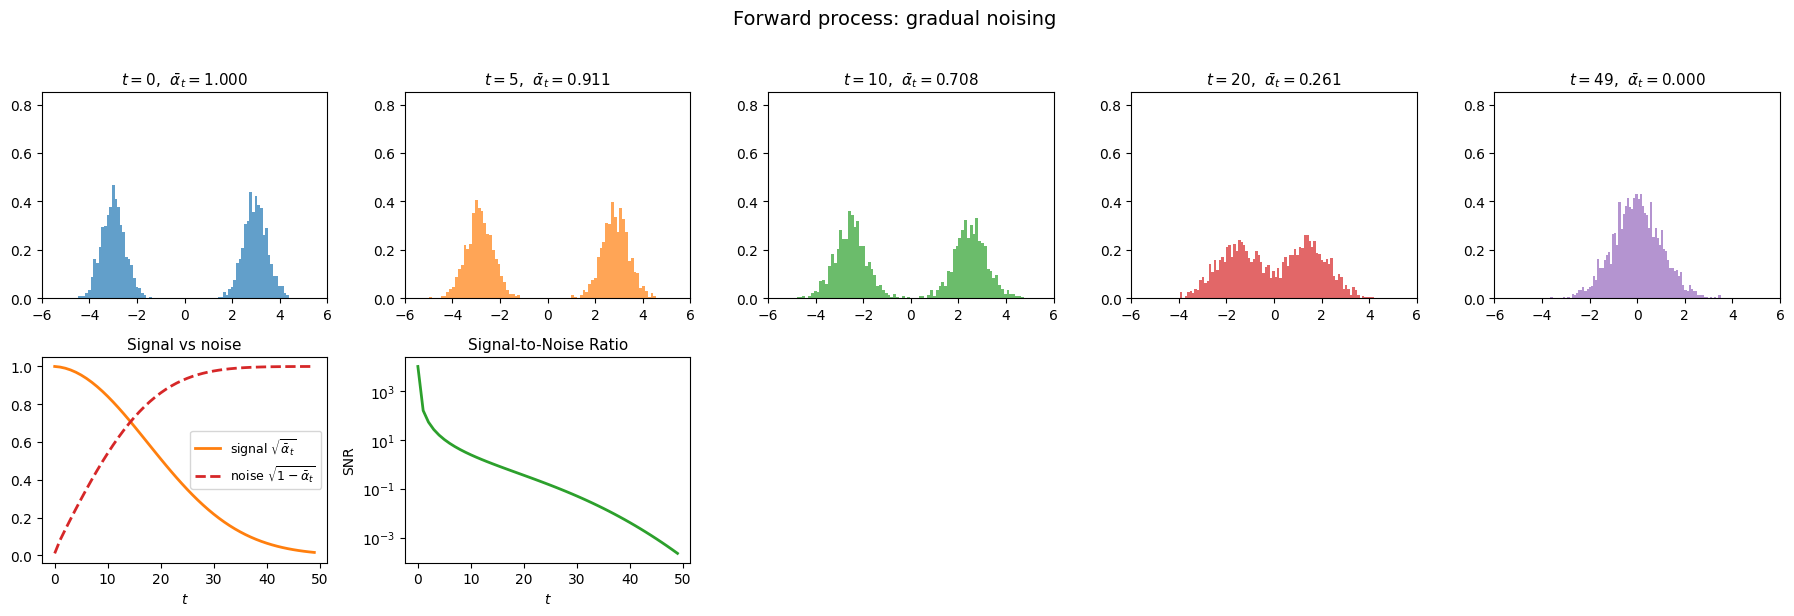

In [15]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

T = 50
betas = np.linspace(1e-4, 0.3, T)
alphas = 1.0 - betas
alpha_bar = np.cumprod(alphas)

# data is a mixture of two gaussians
n_samples = 2000
data = np.concatenate([
    np.random.randn(n_samples // 2) * 0.5 + 3,
    np.random.randn(n_samples // 2) * 0.5 - 3
])

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
steps_to_show = [0, 5, 10, 20, 49]

for idx, t in enumerate(steps_to_show):
    noise = np.random.randn(len(data))
    z_t = np.sqrt(alpha_bar[t]) * data + np.sqrt(1 - alpha_bar[t]) * noise
    
    axes[0, idx].hist(z_t, bins=80, density=True, alpha=0.7, color=f'C{idx}')
    axes[0, idx].set_title(f'$t = {t}$,  $\\bar{{\\alpha}}_t = {alpha_bar[t]:.3f}$', fontsize=11)
    axes[0, idx].set_xlim(-6, 6)
    axes[0, idx].set_ylim(0, 0.85)

# 
t_range = np.arange(T)
snr = alpha_bar / (1 - alpha_bar)


axes[1, 0].plot(t_range, np.sqrt(alpha_bar), 'C1-', lw=2, label=r'signal $\sqrt{\bar\alpha_t}$')
axes[1, 0].plot(t_range, np.sqrt(1 - alpha_bar), 'C3--', lw=2, label=r'noise $\sqrt{1-\bar\alpha_t}$')
axes[1, 0].set_xlabel('$t$')
axes[1, 0].legend(fontsize=9)
axes[1, 0].set_title('Signal vs noise', fontsize=11)

axes[1, 1].semilogy(t_range, snr, 'C2-', lw=2)
axes[1, 1].set_xlabel('$t$')
axes[1, 1].set_ylabel('SNR')
axes[1, 1].set_title('Signal-to-Noise Ratio', fontsize=11)

for i in [2, 3, 4]:
    axes[1, i].axis('off')

plt.suptitle('Forward process: gradual noising', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Forward-процесс на реальных изображениях MNIST

Посмотрим, как forward-процесс работает на реальных объектах (так полюбившимся в нашем курсе). Используя свернутую форму $q(z_t \mid x) = \mathcal{N}(\sqrt{\bar\alpha_t}\, x,\, (1-\bar\alpha_t)\, I)$, мы можем зашумить изображение до произвольного шага $t$ за одну операцию:

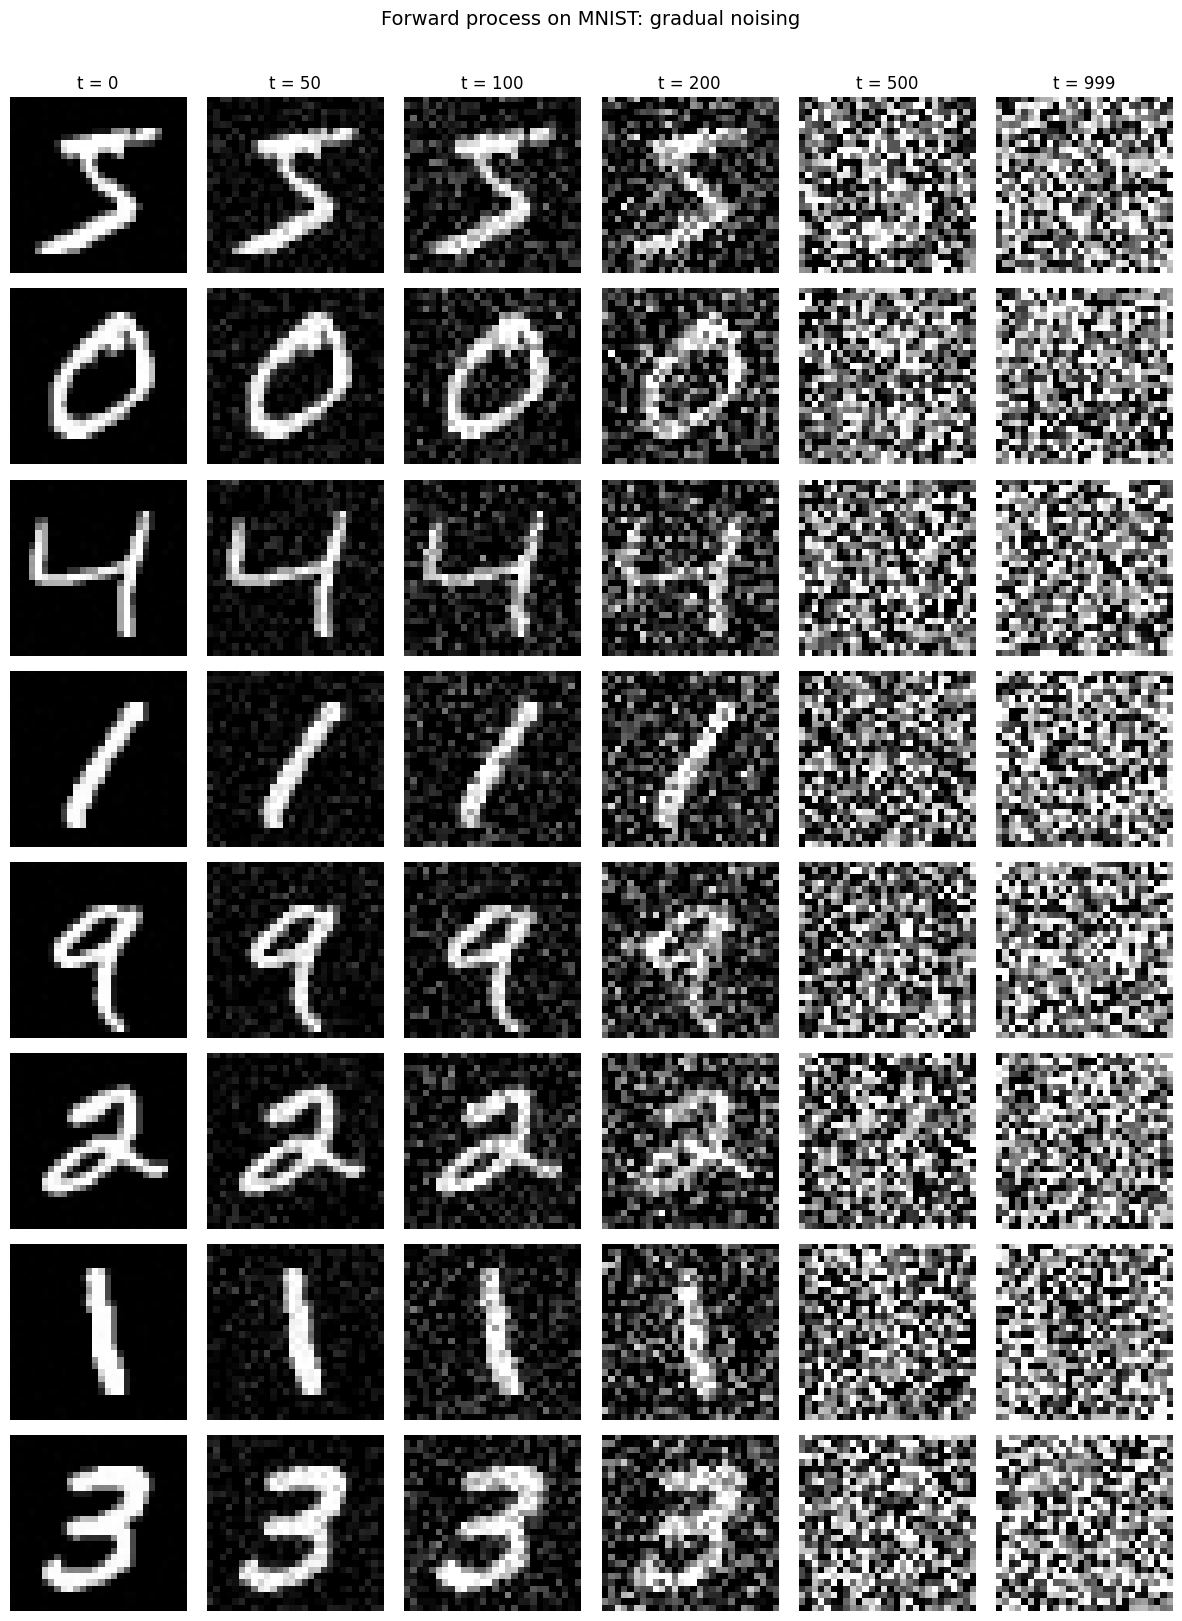

In [16]:
import torch
import torchvision
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
import numpy as np

# Load a few MNIST digits
data = MNIST('data/mnist', download=True, train=True)
images = data.data[:8].float() / 255.0 * 2 - 1  # (8, 28, 28), [-1, 1]
images = images.unsqueeze(1)  # (8, 1, 28, 28)

# VP schedule
T = 1000
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

# Show noising at different timesteps
timesteps = [0, 50, 100, 200, 500, 999]
fig, axes = plt.subplots(8, len(timesteps), figsize=(len(timesteps) * 2, 16))

for col, t in enumerate(timesteps):
    for row in range(8):
        x = images[row]
        eps = torch.randn_like(x)
        z_t = alpha_bar[t].sqrt() * x + (1 - alpha_bar[t]).sqrt() * eps
        img = (z_t.squeeze().numpy() + 1) / 2  # back to [0, 1]
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[0, col].set_title(f't = {t}', fontsize=12)

plt.suptitle('Forward process on MNIST: gradual noising', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Заметим характерную иерархию: при малых $t$ ($t < 100$) изменения практически незаметны — цифры чётко читаются. При средних $t$ ($\sim 200{-}500$) контуры ещё угадываются, но детали уже потеряны. При $t \to T$ изображение неотличимо от чистого шума.

### Reverse (обратный) процесс — денойзинг

Обратный процесс — это то, что мы реально параметризуем нейросетью:

$$p_{\theta, t}(z_{t-1} \mid z_t) = \mathcal{N}\!\left(z_{t-1};\, \mu_\theta(z_t, t),\, \Sigma_\theta(z_t, t)\right)$$

Нейросеть $\mu_\theta$ принимает на вход текущее зашумлённое состояние $z_t$ и номер шага $t$, и предсказывает параметры гауссова перехода на один шаг назад.

Генерация нового объекта тогда сводится к простому алгоритму:

**Алгоритм генерации (DDPM):**
1. Семплировать $z_T \sim \mathcal{N}(0, I)$
2. Для $t = T, T-1, \ldots, 1$: семплировать $z_{t-1} \sim p_{\theta, t}(z_{t-1} \mid z_t)$
3. Вернуть $x \approx z_0$

## Вывод функционала ELBO

Поскольку диффузионная модель — это частный случай латентной модели, мы можем будем выводить вариационную нижнюю оценку (ELBO) так же, как это было для VAE:

$$\log p_\theta(x) = \log \int p_\theta(x, z_{1:T}) \, dz_{1:T} = \log \int \frac{p_\theta(x, z_{1:T})}{q(z_{1:T} \mid x)} \, q(z_{1:T} \mid x) \, dz_{1:T}$$

$$\geq \mathbb{E}_{q(z_{1:T} \mid x)} \left[\log \frac{p_\theta(x, z_{1:T})}{q(z_{1:T} \mid x)}\right] =: \mathcal{L}_{\text{ELBO}}(x; \theta)$$

Подставляя разложение марковской цепи $p_\theta(x, z_{1:T}) = p(z_T) \prod_{t=1}^{T} p_\theta(z_{t-1} \mid z_t)$ и $q(z_{1:T} \mid x) = \prod_{t=1}^{T} q(z_t \mid z_{t-1})$ (при $z_0 = x$), после алгебраических преобразований получаем:

$$\mathcal{L}_{\text{ELBO}}(x; \theta) = \underbrace{\mathbb{E}_{q(z_1|x)}\left[\log p_\theta(x \mid z_1)\right]}_{-L_0\text{ (реконструкция)}} - \underbrace{\text{KL}\!\left(q(z_T \mid x) \,\|\, p(z_T)\right)}_{L_T\text{ (prior matching)}} - \underbrace{\sum_{t=2}^{T} \mathbb{E}_{q(z_t|x)}\left[\text{KL}\!\left(q(z_{t-1} \mid z_t, x) \,\|\, p_\theta(z_{t-1} \mid z_t)\right)\right]}_{\sum_{t=2}^{T} L_{t-1}\text{ (denoising matching)}}$$

Разберём три слагаемых:

**$L_0$ (реконструкция)** — аналог реконструкционного слагаемого в VAE. Отвечает за качество восстановления объекта из первого (почти чистого) латента $z_1$. Как правило, реализуется тривиально или отдельным декодером.

**$L_T$ (prior matching)** — KL-дивергенция между $q(z_T \mid x)$ и прайором $p(z_T) = \mathcal{N}(0, I)$. При достаточно большом $T$ и правильном расписании $\bar\alpha_T \approx 0$, так что $q(z_T \mid x) \approx \mathcal{N}(0, I)$ и это слагаемое практически равно нулю. **Не зависит от параметров $\theta$** — не вносит вклад в градиент.

**$L_{t-1}$ (denoising matching)** — основная сумма. Каждое слагаемое требует, чтобы обученный обратный переход $p_\theta(z_{t-1} \mid z_t)$ был близок к «истинному» обратному переходу $q(z_{t-1} \mid z_t, x)$. Именно эта сумма и является основным обучающим функционалом диффузионной модели.

### Сравнение с ELBO для VAE

| | VAE | Диффузионная модель |
|---|---|---|
| Латентные переменные | $z$ (одна) | $z_1, z_2, \ldots, z_T$ (цепочка) |
| Прайор | $p(z) = \mathcal{N}(0, I)$ | $p(z_T) = \mathcal{N}(0, I)$ |
| Энкодер | $q_\phi(z \mid x)$ — **обучаемый** | $q(z_{1:T} \mid x)$ — **фиксированный** |
| Декодер | $p_\theta(x \mid z)$ — один шаг | $\prod_{t=1}^T p_\theta(z_{t-1} \mid z_t)$ — $T$ шагов |
| ELBO | $\mathbb{E}[\log p_\theta(x \mid z)] - \text{KL}(q_\phi \| p)$ | $-L_0 - L_T - \sum L_{t-1}$ |
| Что оптимизируем | $\theta$ (декодер) и $\phi$ (энкодер) | Только $\theta$ (обратный процесс) |

Если положить $T = 1$, то диффузионная модель в точности сводится к VAE с фиксированным энкодером $q(z_1 \mid x) = \mathcal{N}(\sqrt{\alpha_1}\, x,\, (1-\alpha_1)\, I)$.

## VE vs VP процессы

Помимо VP-расписания существует альтернативное семейство — **VE (Variance Exploding)**:

| Свойство | VP (Variance Preserving) | VE (Variance Exploding) |
|---|---|---|
| Свернутая форма | $q(z_t \mid x) = \mathcal{N}(\sqrt{\bar\alpha_t}\, x,\, (1-\bar\alpha_t)\, I)$ | $q(z_t \mid x) = \mathcal{N}(x,\, \sigma_t^2\, I)$ |
| Среднее | Затухает: $\sqrt{\bar\alpha_t} \to 0$ | Постоянное: $x$ |
| Дисперсия | Ограничена: $\leq 1$ | Растёт: $\sigma_t^2 \to \infty$ |
| Конечное распределение | $\mathcal{N}(0, I)$ | $\mathcal{N}(0, \sigma_{\max}^2 I)$ |
| Стабильность | Более стабильное обучение | Может быть нестабильно при больших $\sigma$ |

В VP-процессе сигнал затухает одновременно с ростом шума, так что общая дисперсия остаётся примерно единичной (отсюда имя «variance preserving»). В VE-процессе среднее не меняется, а дисперсия растёт неограниченно.

На практике VP-процессы используются чаще благодаря более стабильной оптимизации. Важное теоретическое наблюдение: оба процесса могут быть преобразованы друг в друга заменой параметров, поэтому модель, обученная с VP, в принципе может использоваться с VE-расписанием.

<p align="center">
  <img src="images/lecture_4/ve-vp.png" style="width:90%;">
</p>

## VP-schedule 

Огромное преимущество гауссова ядра: композиция нескольких гауссовых переходов — тоже гауссов переход. Определим кумулятивный параметр:

$$\bar\alpha_t = \prod_{s=1}^{t} \alpha_s$$

Тогда свернутая форма прямого процесса позволяет **зашумить объект сразу до произвольного шага $t$**:

$$q(z_t \mid x) = \mathcal{N}\!\left(z_t;\, \sqrt{\bar\alpha_t}\, x,\, (1 - \bar\alpha_t)\, I\right)$$

Это записывается через репараметризацию:

$$z_t = \sqrt{\bar\alpha_t}\, x + \sqrt{1 - \bar\alpha_t}\, \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$

### Обратный переход при известном $x$

Для вычисления KL-дивергенций в ELBO нам нужен «истинный» обратный переход $q(z_{t-1} \mid z_t, x)$. По формуле Байеса:

$$q(z_{t-1} \mid z_t, x) = \frac{q(z_t \mid z_{t-1}) \, q(z_{t-1} \mid x)}{q(z_t \mid x)}$$

Поскольку все три распределения гауссовы, их произведение тоже гауссово:

$$q(z_{t-1} \mid z_t, x) = \mathcal{N}\!\left(z_{t-1};\, \tilde\mu_t(x, z_t),\, \tilde\beta_t\, I\right)$$

где:

$$\tilde\mu_t(x, z_t) = \frac{\sqrt{\bar\alpha_{t-1}}\,(1 - \alpha_t)}{1 - \bar\alpha_t}\, x \;+\; \frac{\sqrt{\alpha_t}\,(1 - \bar\alpha_{t-1})}{1 - \bar\alpha_t}\, z_t$$

$$\tilde\beta_t = \frac{(1 - \bar\alpha_{t-1})}{(1 - \bar\alpha_t)}\,(1 - \alpha_t)$$

Заметим, что среднее $\tilde\mu_t$ — линейная функция от $x$ и $z_t$, а дисперсия $\tilde\beta_t$ зависит только от расписания шума и не зависит от данных.

## Параметризация сети


Промежуточные слагаемые ELBO имеют вид:

$$L_{t-1} \propto \mathbb{E}_{x, z_t}\left[\frac{1}{2\tilde\beta_t} \left\|\tilde\mu_t(x, z_t) - \mu_\theta(z_t, t)\right\|^2\right]$$

Вопрос: **что именно предсказывает нейросеть** $\mu_\theta(z_t, t)$? Поскольку $\tilde\mu_t(x, z_t)$ — линейная функция от $(x, z_t)$, а $z_t = \sqrt{\bar\alpha_t}\, x + \sqrt{1-\bar\alpha_t}\,\varepsilon$, существуют три естественных параметризации:

### $\mu$-параметризация

Сеть непосредственно аппроксимирует среднее обратного перехода: $\mu_\theta(z_t, t) \approx \tilde\mu_t(x, z_t)$

**Недостаток:** целевая величина $\tilde\mu_t$ сильно зависит от $t$ — задача регрессии неоднородна по времени.

### $x_0$-параметризация

Сеть предсказывает $\hat{x}_\theta(z_t, t) \approx x$

**Интерпретация:** сеть пытается восстановить чистый объект из зашумлённого.

### $\varepsilon$-параметризация (стандарт де-факто)

Подставляя $x = \frac{z_t - \sqrt{1-\bar\alpha_t}\,\varepsilon}{\sqrt{\bar\alpha_t}}$ в формулу для $\tilde\mu_t$, получаем:

$$\tilde\mu_t(x, z_t) = \frac{1}{\sqrt{\alpha_t}}\left(z_t - \frac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon\right)$$

Сеть $\varepsilon_\theta(z_t, t)$ предсказывает **шум**, который был добавлен:

$$L_{t-1} \propto \mathbb{E}_{x, \varepsilon, t}\left[\left\|\varepsilon - \varepsilon_\theta(z_t, t)\right\|^2\right], \quad z_t = \sqrt{\bar\alpha_t}\, x + \sqrt{1-\bar\alpha_t}\,\varepsilon$$

**Ключевое преимущество:** целевая переменная $\varepsilon \sim \mathcal{N}(0, I)$ **всегда одинаково распределена** вне зависимости от $t$. Вся информация о номере шага кодируется через входы сети $(z_t, t)$, а не через распределение таргета. Это делает задачу регрессии более стационарной.

## Алгоритм обучения DDPM

Повторять до сходимости:
1) $x ~ p*(x)$ – батч из датасета
2) $t \sim \mathcal{U}\{1, ..., T\}$
3) $\varepsilon \sim \mathcal{N}(0, I)$
4) $z_t = \sqrt{\bar{\alpha}_t} \cdot x + \sqrt{1 - \bar{\alpha}_t} * \varepsilon$
5) $\theta_t \gets \theta_{t-1} + \gamma \cdot \text{step}(\|\varepsilon -  \varepsilon_\theta(z_t, t)\|)$

### Алгоритм генерации DDPM

1) $z_T \sim\mathcal{N}(0, I)$
2) для $t = T, T-1, \ldots, 1$:
   - если $t > 1$: $\sigma \sim \mathcal{N}(0, I)$, иначе $\sigma = 0$
   - $z_{t-1} = \dfrac{1}{\sqrt{\alpha_t}}\left(z_t - \dfrac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}}\,\varepsilon_\theta(z_t, t)\right) + \sqrt{\beta_t}\,\sigma$
3) вернуть $x = z_0$


## Архитектура U-Net для денойзинга


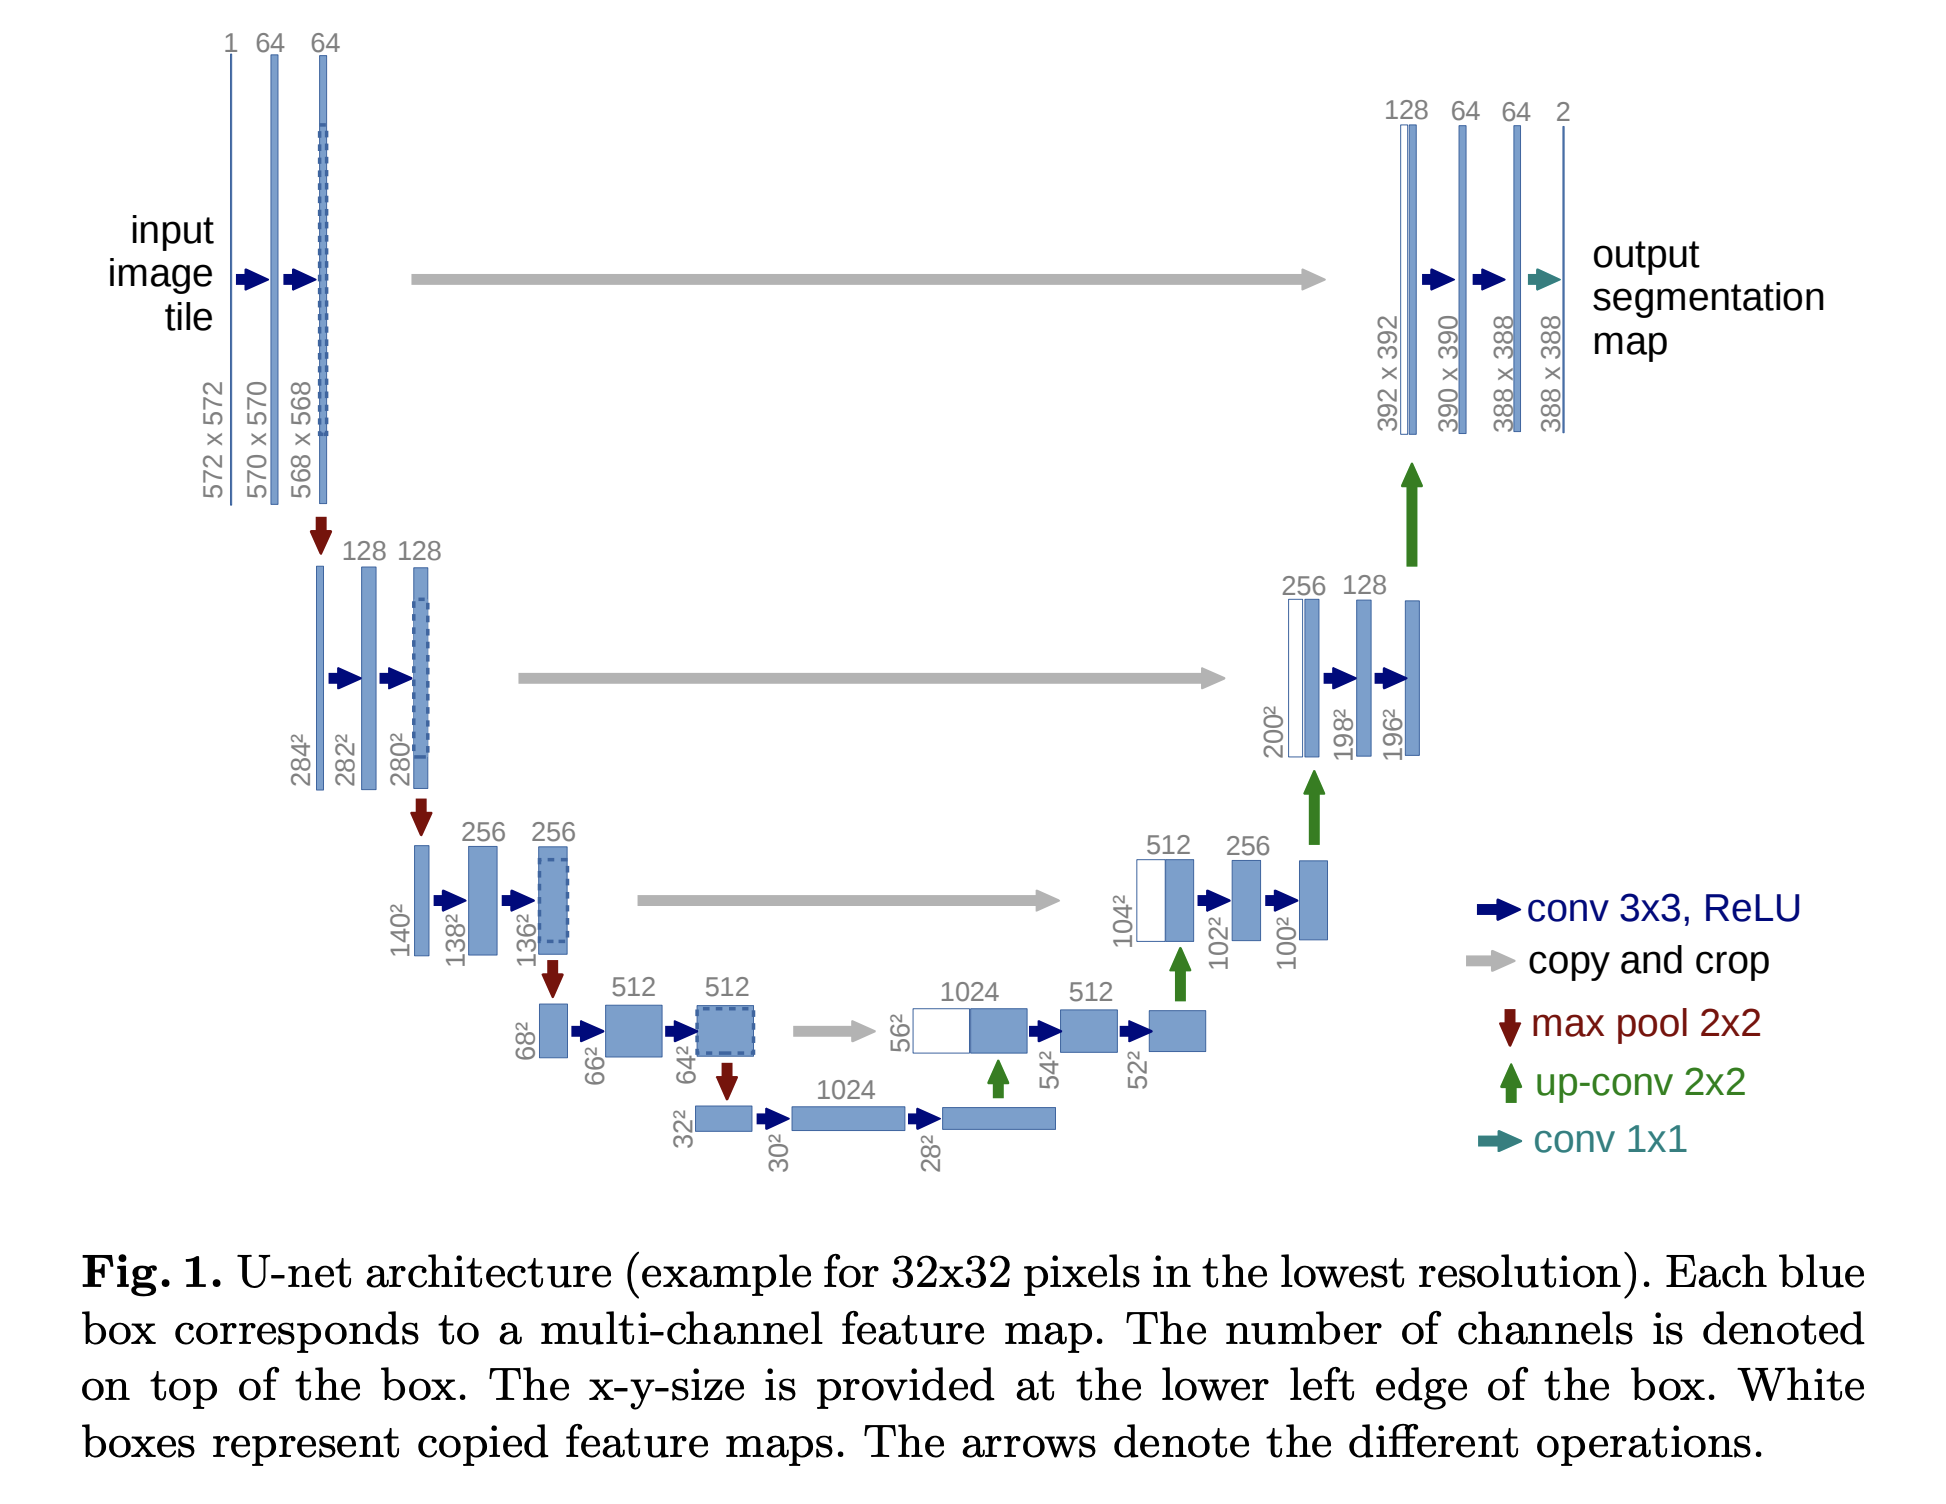



Нейросеть $\varepsilon_\theta(z_t, t)$ принимает на вход зашумлённый объект $z_t$ той же размерности, что и данные, и номер шага $t$, и возвращает предсказанный шум той же размерности. Для изображений стандартная архитектура — **U-Net**, адаптированный для задачи денойзинга.

### Почему именно U-Net

1. **Skip connections** — сохраняют высокочастотные детали, которые иначе теряются при прохождении через bottleneck. Для задачи восстановления шума это критически важно.

2. **Encoder-decoder структура** — позволяет работать на разных масштабах разрешения.

3. **Вход и выход одной размерности** — по конструкции U-Net даёт выход той же формы, что и вход.


## Реализация DDPM

Перейдём к полной реализации DDPM для генерации изображений MNIST.

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import MNIST
import torchvision
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [21]:
# === Data ===
data_train = MNIST('data/mnist', download=True, train=True)
data_test  = MNIST('data/mnist', download=True, train=False)

# Normalize to [-1, 1]
X_train = data_train.data.float().unsqueeze(1) / 255.0 * 2 - 1
X_test  = data_test.data.float().unsqueeze(1)  / 255.0 * 2 - 1

train_loader = DataLoader(TensorDataset(X_train), batch_size=128, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test),  batch_size=128, shuffle=False)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: torch.Size([60000, 1, 28, 28]), Test: torch.Size([10000, 1, 28, 28])


Данные нормализованы в $[-1, 1]$ — это стандартная практика для диффузионных моделей. В отличие от VAE, где мы часто работали с $[0, 1]$ и Bernoulli-декодером, здесь вход и выход модели живут в непрерывном пространстве, и симметричная нормализация обеспечивает лучшую совместимость с гауссовым прайором $\mathcal{N}(0, I)$.

In [22]:
# === Noise Schedule ===
class NoiseSchedule:
    '''VP (variance-preserving) linear noise schedule.'''
    
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.T = T
        self.device = device
        self.betas = torch.linspace(beta_start, beta_end, T, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)
        self.alpha_bar_prev = F.pad(self.alpha_bar[:-1], (1, 0), value=1.0)
        self.posterior_variance = self.betas * (1.0 - self.alpha_bar_prev) / (1.0 - self.alpha_bar)
    
    def q_sample(self, x0, t, noise=None):
        '''Forward process: sample z_t from q(z_t | x_0).'''
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_alpha_bar = self.alpha_bar[t].sqrt()[:, None, None, None]
        sqrt_one_minus = (1.0 - self.alpha_bar[t]).sqrt()[:, None, None, None]
        return sqrt_alpha_bar * x0 + sqrt_one_minus * noise, noise
    
schedule = NoiseSchedule(T=1000, device=device)
print(f'Schedule: T={schedule.T}, beta=[{schedule.betas[0]:.5f}, {schedule.betas[-1]:.4f}]')

Schedule: T=1000, beta=[0.00010, 0.0200]


Класс `NoiseSchedule` инкапсулирует все параметры расписания: $\beta_t$, $\alpha_t$, $\bar\alpha_t$, а также дисперсию обратного перехода $\tilde\beta_t$. Метод `q_sample` реализует свернутую форму forward-процесса — именно эта операция будет вызываться на каждом шаге обучения.

In [30]:
# === Sinusoidal time embedding ===
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return emb


# === Residual block with time conditioning ===
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Sequential(nn.GroupNorm(8, in_ch), nn.SiLU(), nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch))
        self.conv2 = nn.Sequential(nn.GroupNorm(8, out_ch), nn.SiLU(), nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    
    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.conv2(h)
        return h + self.shortcut(x)


# === Simple U-Net for MNIST (28x28) ===
class SimpleUNet(nn.Module):
    '''Simplified U-Net for DDPM on MNIST. Encoder: 28->14->7, Decoder: 7->14->28.'''
    def __init__(self, in_channels=1, base_channels=64, time_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim * 2), nn.SiLU(), nn.Linear(time_dim * 2, time_dim))
        C = base_channels
        # Input projection: 1 -> C (чтобы GroupNorm(8, ...) работал)
        self.input_proj = nn.Conv2d(in_channels, C, 3, padding=1)
        # Encoder
        self.enc1 = ResBlock(C, C, time_dim)
        self.down1 = nn.Conv2d(C, C, 3, stride=2, padding=1)
        self.enc2 = ResBlock(C, C * 2, time_dim)
        self.down2 = nn.Conv2d(C * 2, C * 2, 3, stride=2, padding=1)
        # Bottleneck
        self.bottleneck = ResBlock(C * 2, C * 2, time_dim)
        # Decoder
        self.up2 = nn.ConvTranspose2d(C * 2, C * 2, 4, stride=2, padding=1)
        self.dec2 = ResBlock(C * 4, C, time_dim)
        self.up1 = nn.ConvTranspose2d(C, C, 4, stride=2, padding=1)
        self.dec1 = ResBlock(C * 2, C, time_dim)
        # Output
        self.out = nn.Sequential(nn.GroupNorm(8, C), nn.SiLU(), nn.Conv2d(C, in_channels, 1))
    
    def forward(self, x, t):
        '''Predict noise eps_theta(z_t, t). x: (B,C,H,W), t: (B,).'''
        t_emb = self.time_mlp(t)
        x = self.input_proj(x)              # (B, 1, 28, 28) -> (B, C, 28, 28)
        h1 = self.enc1(x, t_emb)
        h2 = self.enc2(self.down1(h1), t_emb)
        h = self.bottleneck(self.down2(h2), t_emb)
        h = self.up2(h)
        h = self.dec2(torch.cat([h, h2], 1), t_emb)
        h = self.up1(h)
        h = self.dec1(torch.cat([h, h1], 1), t_emb)
        return self.out(h)

model = SimpleUNet(in_channels=1, base_channels=64, time_dim=128).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')

Model parameters: 1,557,761


Архитектура нашей U-Net достаточно компактна для MNIST: три уровня разрешения ($28 \to 14 \to 7$), residual blocks с time conditioning через сложение, skip connections через конкатенацию. Для более сложных данных (CIFAR-10, ImageNet) добавляют self-attention блоки, больше каналов и больше уровней.

In [ ]:
# === Training loop ===
def train_ddpm(model, schedule, train_loader, num_epochs=20, lr=2e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(num_epochs):
        model.train()
        epoch_loss, n_batches = 0, 0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for (x0,) in pbar:
            x0 = x0.to(device)
            B = x0.shape[0]
            t = torch.randint(0, schedule.T, (B,), device=device)
            noise = torch.randn_like(x0)
            z_t, _ = schedule.q_sample(x0, t, noise)
            noise_pred = model(z_t, t)
            loss = F.mse_loss(noise_pred, noise)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
            pbar.set_postfix(loss=f'{loss.item():.4f}')
        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        print(f'  Epoch {epoch+1}: avg loss = {avg_loss:.4f}')
    return losses

losses = train_ddpm(model, schedule, train_loader, num_epochs=20, lr=2e-4)

# === Save checkpoint ===
import os
os.makedirs('checkpoints', exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'losses': losses,
}, 'checkpoints/ddpm_mnist.pt')
print('Checkpoint saved to checkpoints/ddpm_mnist.pt')

Epoch 1/20: 100%|██████████| 469/469 [00:08<00:00, 53.40it/s, loss=0.0297]


  Epoch 1: avg loss = 0.0643


Epoch 2/20: 100%|██████████| 469/469 [00:06<00:00, 67.10it/s, loss=0.0376]


  Epoch 2: avg loss = 0.0323


Epoch 3/20: 100%|██████████| 469/469 [00:06<00:00, 67.77it/s, loss=0.0280]


...

  Epoch 18: avg loss = 0.0229


Epoch 19/20: 100%|██████████| 469/469 [00:06<00:00, 67.76it/s, loss=0.0213]


  Epoch 19: avg loss = 0.0228


Epoch 20/20: 100%|██████████| 469/469 [00:06<00:00, 67.41it/s, loss=0.0199]

  Epoch 20: avg loss = 0.0228


In [39]:
# === Load checkpoint (если уже обучали ранее) ===
ckpt = torch.load('checkpoints/ddpm_mnist.pt', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
losses = ckpt['losses']
print(f'Loaded checkpoint, {len(losses)} epochs, final loss = {losses[-1]:.4f}')

Loaded checkpoint, 20 epochs, final loss = 0.0228


Обратите внимание на простоту цикла обучения: на каждой итерации мы семплируем случайный шаг $t$, зашумляем батч, предсказываем шум и считаем MSE. Никаких adversarial-потерь (как в GAN), никакого KL-дивергенции энкодера (как в VAE) — только один простой $L_2$-loss.

In [48]:
# === DDPM Sampling ===
@torch.no_grad()
def sample_ddpm(model, schedule, n_samples=64, return_intermediates=False, intermediate_each_step=200):
    '''DDPM sampling: z_T ~ N(0,I) -> z_{T-1} -> ... -> z_0.'''
    model.eval()
    shape = (n_samples, 1, 28, 28)
    z = torch.randn(shape, device=device)
    intermediates = [z.cpu()] if return_intermediates else None
    for t in tqdm(reversed(range(schedule.T)), total=schedule.T, desc='Sampling'):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        eps_pred = model(z, t_batch)
        alpha_t = schedule.alphas[t]
        alpha_bar_t = schedule.alpha_bar[t]
        beta_t = schedule.betas[t]
        mean = (1.0 / alpha_t.sqrt()) * (z - (beta_t / (1 - alpha_bar_t).sqrt()) * eps_pred)
        if t > 0:
            noise = torch.randn_like(z)
            sigma = schedule.posterior_variance[t].sqrt()
            z = mean + sigma * noise
        else:
            z = mean
        if return_intermediates and t % intermediate_each_step == 0:
            intermediates.append(z.cpu())
    if return_intermediates:
        return z.cpu(), intermediates
    return z.cpu()

Sampling: 100%|██████████| 1000/1000 [00:02<00:00, 418.38it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.02360648..1.0134915].


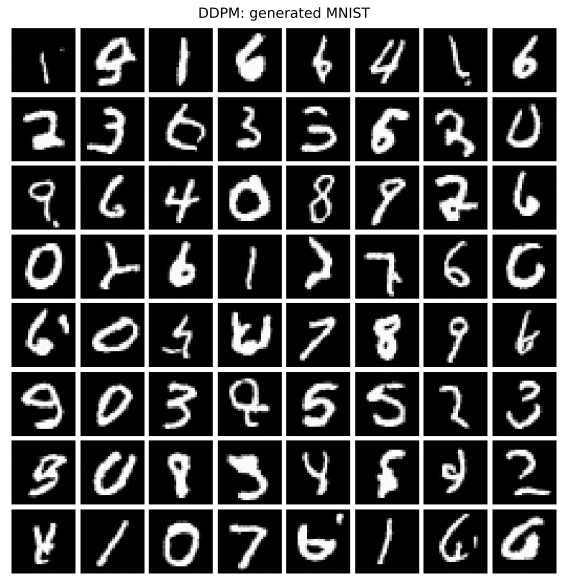

In [49]:
# === Генерация 64 сэмплов ===
samples = sample_ddpm(model, schedule, n_samples=64)
samples = (samples + 1) / 2  # [-1,1] -> [0,1]

fig = plt.figure(figsize=(10, 10))
grid = torchvision.utils.make_grid(samples, nrow=8, pad_value=1)
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
plt.axis('off')
plt.title('DDPM: generated MNIST', fontsize=14)
plt.show()

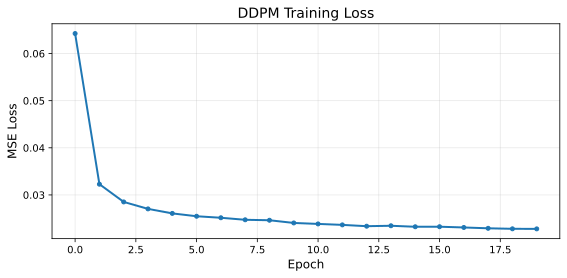

In [44]:
# === Кривая обучения ===
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, 'C0-', lw=2, marker='o', markersize=4)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('DDPM Training Loss', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Sampling: 100%|██████████| 1000/1000 [00:01<00:00, 567.87it/s]


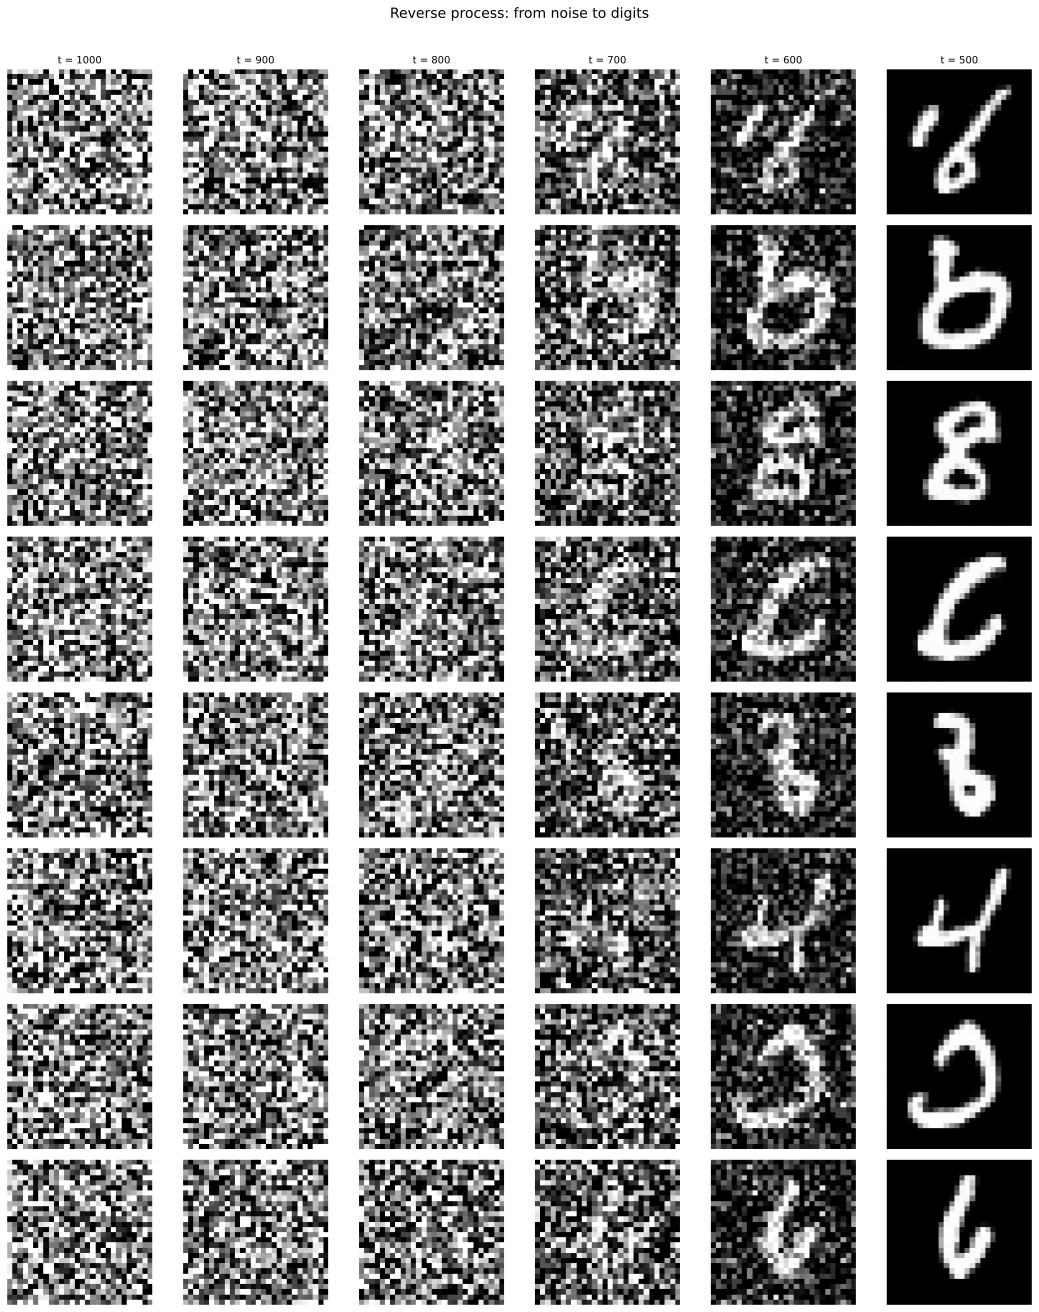

In [52]:
# === Пошаговое расшумление ===
samples_vis, intermediates = sample_ddpm(model, schedule, n_samples=8, return_intermediates=True)

n_steps_shown = len(intermediates)
fig, axes = plt.subplots(8, n_steps_shown, figsize=(2.5 * n_steps_shown, 18))

for row in range(8):
    for col in range(n_steps_shown):
        img = (intermediates[col][row, 0] + 1) / 2
        axes[row, col].imshow(img.numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')

# Подписи: t=1000, 900, 800, ...
t_labels = list(range(1000, -1, -100))[:n_steps_shown]
for col in range(n_steps_shown):
    axes[0, col].set_title(f't = {t_labels[col]}', fontsize=10)

plt.suptitle('Reverse process: from noise to digits', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Визуализация обученной модели

После обучения (~15-20 эпох на GPU) модель генерирует вполне узнаваемые рукописные цифры. Качественное отличие от VAE: сгенерированные изображения **значительно более чёткие** и не страдают от характерного «размытия» VAE.

Процесс генерации визуально нагляден: на ранних шагах ($t \approx T$) мы видим чистый шум, затем постепенно проявляется структура — сначала грубые контуры, потом мелкие детали. Это отражает иерархическую природу: **низкие частоты восстанавливаются первыми**, а **высокие — последними**.

## DDIM Sampler

DDIM (Song et al., 2020) позволяет генерировать с **произвольным числом шагов** $S \ll T$. Идея заключается в предсказании вместо $x_t \sim p(x_t \mid x_{t+1}, x_0)$ распределения другого $x_\ell \sim p (x_\ell \mid x_{t+1}, x_0), \ell < t$. Точные формулы восстанавливаются напрямую из теоремы Байеса

In [ ]:
# === DDIM Sampler ===
@torch.no_grad()
def sample_ddim(model, schedule, n_samples=64, n_steps=50):
    '''DDIM sampling with arbitrary number of steps.'''
    model.eval()
    
    step_indices = list(np.linspace(0, schedule.T - 1, n_steps, dtype=int))
    step_indices = sorted(set(step_indices), reverse=True)
    
    z = torch.randn(n_samples, 1, 28, 28, device=device)
    
    for i in range(len(step_indices)):
        t = step_indices[i]
        t_prev = step_indices[i + 1] if i + 1 < len(step_indices) else 0
        
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        eps_pred = model(z, t_batch)
        
        alpha_bar_t = schedule.alpha_bar[t]
        alpha_bar_prev = schedule.alpha_bar[t_prev] if t_prev > 0 else torch.tensor(1.0, device=device)
        
        # Predicted x_0
        x0_pred = (z - (1 - alpha_bar_t).sqrt() * eps_pred) / alpha_bar_t.sqrt()
        
        # DDIM update (deterministic)
        z = alpha_bar_prev.sqrt() * x0_pred + (1 - alpha_bar_prev).sqrt() * eps_pred
    
    return z.cpu()

In [ ]:
# === Сравнение DDIM при разном числе шагов ===
import time

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
step_counts = [1000, 100, 50, 10]
titles = ['DDPM\n(1000 steps)', 'DDIM\n(100 steps)', 'DDIM\n(50 steps)', 'DDIM\n(10 steps)']

torch.manual_seed(42)
z_T_fixed = torch.randn(16, 1, 28, 28, device=device)

for ax, n_steps, title in zip(axes, step_counts, titles):
    torch.manual_seed(42)  # same initial noise for fair comparison
    start = time.time()
    
    if n_steps == 1000:
        # Full DDPM
        model.eval()
        z = z_T_fixed.clone()
        with torch.no_grad():
            for t in reversed(range(schedule.T)):
                t_batch = torch.full((16,), t, device=device, dtype=torch.long)
                eps_pred = model(z, t_batch)
                alpha_t = schedule.alphas[t]
                alpha_bar_t = schedule.alpha_bar[t]
                beta_t = schedule.betas[t]
                mean = (1.0 / alpha_t.sqrt()) * (z - (beta_t / (1 - alpha_bar_t).sqrt()) * eps_pred)
                if t > 0:
                    z = mean + schedule.posterior_variance[t].sqrt() * torch.randn_like(z)
                else:
                    z = mean
        samples = z.cpu()
    else:
        samples = sample_ddim(model, schedule, n_samples=16, n_steps=n_steps)
    
    elapsed = time.time() - start
    samples_vis = (samples + 1) / 2
    grid = torchvision.utils.make_grid(samples_vis, nrow=4, pad_value=1)
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    ax.set_title(f'{title}\n({elapsed:.1f}s)', fontsize=11)
    ax.axis('off')

plt.suptitle('Speed vs quality: DDPM vs DDIM', fontsize=14)
plt.tight_layout()
plt.show()

### Интерполяция в пространстве шума

Одно из интересных свойств диффузионных моделей (особенно с DDIM): если зафиксировать два начальных шума $z_T^{(1)}$ и $z_T^{(2)}$ и линейно интерполировать между ними, reverse-процесс даёт плавный переход между объектами:

$$z_T^{(\lambda)} = \lambda\, z_T^{(1)} + (1-\lambda)\, z_T^{(2)}, \quad \lambda \in [0, 1]$$

In [ ]:
# === Интерполяция в пространстве шума ===
torch.manual_seed(123)
z1 = torch.randn(1, 1, 28, 28, device=device)
z2 = torch.randn(1, 1, 28, 28, device=device)

n_interp = 10
lambdas = np.linspace(0, 1, n_interp)
z_interp = torch.cat([lam * z1 + (1 - lam) * z2 for lam in lambdas], dim=0)

# DDIM from interpolated noise
model.eval()
with torch.no_grad():
    step_indices = list(np.linspace(0, schedule.T - 1, 50, dtype=int))
    step_indices = sorted(set(step_indices), reverse=True)
    z = z_interp.clone()
    for i in range(len(step_indices)):
        t = step_indices[i]
        t_prev = step_indices[i + 1] if i + 1 < len(step_indices) else 0
        t_batch = torch.full((n_interp,), t, device=device, dtype=torch.long)
        eps_pred = model(z, t_batch)
        alpha_bar_t = schedule.alpha_bar[t]
        alpha_bar_prev = schedule.alpha_bar[t_prev] if t_prev > 0 else torch.tensor(1.0, device=device)
        x0_pred = (z - (1 - alpha_bar_t).sqrt() * eps_pred) / alpha_bar_t.sqrt()
        z = alpha_bar_prev.sqrt() * x0_pred + (1 - alpha_bar_prev).sqrt() * eps_pred

samples_interp = (z.cpu() + 1) / 2

fig, axes = plt.subplots(1, n_interp, figsize=(2 * n_interp, 2.5))
for i in range(n_interp):
    axes[i].imshow(samples_interp[i, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[i].axis('off')
    axes[i].set_title(f'$\lambda$={lambdas[i]:.1f}', fontsize=10)
plt.suptitle('Interpolation in noise space (DDIM, 50 steps)', fontsize=13)
plt.tight_layout()
plt.show()

### Анализ качества: что выучила модель

Посмотрим, насколько хорошо модель предсказывает шум для разных $t$. При малых $t$ (мало шума) задача почти тривиальная — шум слабый и легко отделим от сигнала. При больших $t$ (много шума) предсказание сложнее, но модель всё равно извлекает полезную информацию.

In [ ]:
# === Анализ ошибки предсказания шума по шагам t ===
model.eval()
n_test = 1000
mse_per_t = []

t_values = list(range(0, schedule.T, 50))  # каждые 50 шагов
for t_val in tqdm(t_values, desc='Computing MSE per t'):
    with torch.no_grad():
        x0 = X_test[:n_test].to(device)
        t_batch = torch.full((n_test,), t_val, device=device, dtype=torch.long)
        noise = torch.randn_like(x0)
        z_t, _ = schedule.q_sample(x0, t_batch, noise)
        noise_pred = model(z_t, t_batch)
        mse = F.mse_loss(noise_pred, noise).item()
        mse_per_t.append(mse)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_values, mse_per_t, 'C0-o', lw=2, markersize=3)
ax.set_xlabel('Timestep $t$', fontsize=12)
ax.set_ylabel('MSE (noise prediction)', fontsize=12)
ax.set_title('Prediction error vs diffusion step', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# === Визуализация: предсказанный x_0 на разных шагах t ===
model.eval()

# Возьмем одну цифру
x_orig = X_test[3:4].to(device)  # (1, 1, 28, 28)

fig, axes = plt.subplots(2, 7, figsize=(18, 5.5))
t_show = [10, 50, 100, 200, 400, 700, 999]

for col, t_val in enumerate(t_show):
    with torch.no_grad():
        t_batch = torch.full((1,), t_val, device=device, dtype=torch.long)
        noise = torch.randn_like(x_orig)
        z_t, _ = schedule.q_sample(x_orig, t_batch, noise)
        eps_pred = model(z_t, t_batch)
        
        # Predicted x_0 from eps prediction
        alpha_bar_t = schedule.alpha_bar[t_val]
        x0_pred = (z_t - (1 - alpha_bar_t).sqrt() * eps_pred) / alpha_bar_t.sqrt()
    
    # Top row: noisy input z_t
    img_zt = (z_t[0, 0].cpu().numpy() + 1) / 2
    axes[0, col].imshow(img_zt, cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(f't = {t_val}', fontsize=11)
    axes[0, col].axis('off')
    
    # Bottom row: predicted x_0
    img_x0 = (x0_pred[0, 0].cpu().numpy() + 1) / 2
    img_x0 = np.clip(img_x0, 0, 1)
    axes[1, col].imshow(img_x0, cmap='gray', vmin=0, vmax=1)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('$z_t$ (input)', fontsize=12, rotation=90, labelpad=10)
axes[1, 0].set_ylabel('predicted $x_0$', fontsize=12, rotation=90, labelpad=10)

plt.suptitle('What the model "sees": noisy input vs predicted clean image', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Анализ $z_T$ пространства

In [ ]:
def slerp(z1, z2, lam):
    '''Spherical linear interpolation. z1, z2: same shape, lam: scalar in [0,1].'''
    z1_flat = z1.reshape(-1).float()
    z2_flat = z2.reshape(-1).float()
    cos_omega = (z1_flat @ z2_flat) / (z1_flat.norm() * z2_flat.norm() + 1e-8)
    cos_omega = cos_omega.clamp(-1, 1)
    omega = torch.acos(cos_omega)
    if omega.abs() < 1e-6:
        return (1 - lam) * z1 + lam * z2
    s = torch.sin(omega)
    return (torch.sin((1 - lam) * omega) / s) * z1 + (torch.sin(lam * omega) / s) * z2

<p align="center">
  <img src="images/lecture_4/slerp.png" style="width:60%;">
</p>

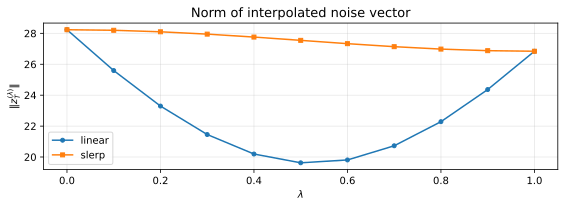

In [ ]:
z1 = torch.randn(1, 1, 28, 28, device=device)
z2 = torch.randn(1, 1, 28, 28, device=device)

n_interp = 11
lambdas = np.linspace(0, 1, n_interp)

z_linear = torch.cat([(1 - lam) * z1 + lam * z2 for lam in lambdas], dim=0)  # (11, 1, 28, 28)
z_slerp  = torch.cat([slerp(z1, z2, lam) for lam in lambdas], dim=0)         # (11, 1, 28, 28)

# Нормы — видим разницу
norms_lin   = [z_linear[i].norm().item() for i in range(n_interp)]
norms_slerp = [z_slerp[i].norm().item() for i in range(n_interp)]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(lambdas, norms_lin, 'C0-o', ms=4, label='linear')
ax.plot(lambdas, norms_slerp, 'C1-s', ms=4, label='slerp')
ax.set_xlabel(r'$\lambda$'); ax.set_ylabel(r'$\|z_T^{(\lambda)}\|$')
ax.set_title('Norm of interpolated noise vector', fontsize=13)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

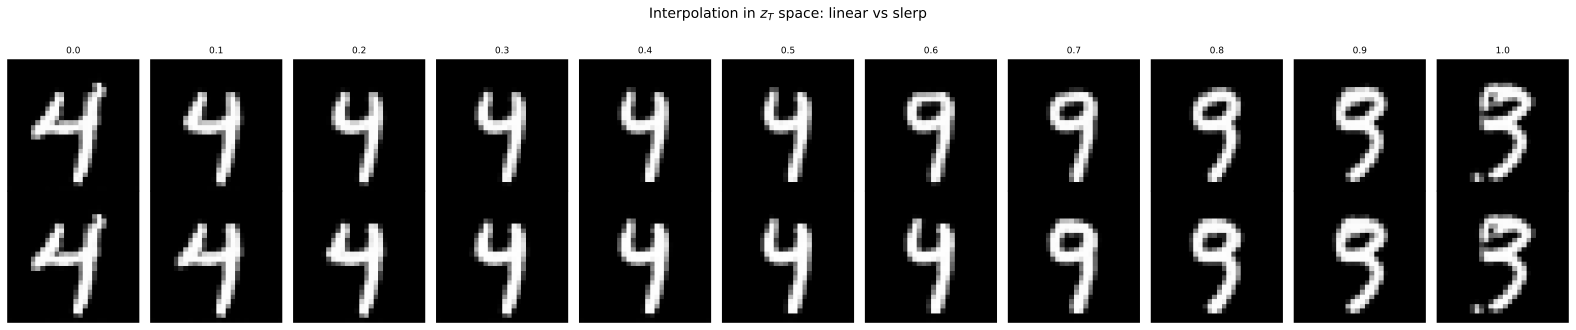

In [ ]:
@torch.no_grad()
def ddim_from_z(model, schedule, z_start, n_steps=50):
    '''Run DDIM reverse process from given z_T. z_start: (B, 1, 28, 28).'''
    model.eval()
    step_indices = sorted(set(np.linspace(0, schedule.T - 1, n_steps, dtype=int)), reverse=True)
    z = z_start.clone()
    for i in range(len(step_indices)):
        t = step_indices[i]
        t_prev = step_indices[i + 1] if i + 1 < len(step_indices) else 0
        B = z.shape[0]
        t_batch = torch.full((B,), t, device=z.device, dtype=torch.long)
        eps_pred = model(z, t_batch)
        ab_t = schedule.alpha_bar[t]
        ab_prev = schedule.alpha_bar[t_prev] if t_prev > 0 else torch.tensor(1.0, device=z.device)
        x0_pred = (z - (1 - ab_t).sqrt() * eps_pred) / ab_t.sqrt()
        z = ab_prev.sqrt() * x0_pred + (1 - ab_prev).sqrt() * eps_pred
    return z

samples_lin   = ddim_from_z(model, schedule, z_linear.to(device))
samples_slerp = ddim_from_z(model, schedule, z_slerp.to(device))

fig, axes = plt.subplots(2, n_interp, figsize=(2 * n_interp, 4.5))
for i in range(n_interp):
    img_lin = (samples_lin[i, 0].cpu().numpy() + 1) / 2
    axes[0, i].imshow(img_lin, cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'{lambdas[i]:.1f}', fontsize=9)
    
    img_slp = (samples_slerp[i, 0].cpu().numpy() + 1) / 2
    axes[1, i].imshow(img_slp, cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('linear', fontsize=11, rotation=90, labelpad=10)
axes[1, 0].set_ylabel('slerp', fontsize=11, rotation=90, labelpad=10)
plt.suptitle(r'Interpolation in $z_T$ space: linear vs slerp', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

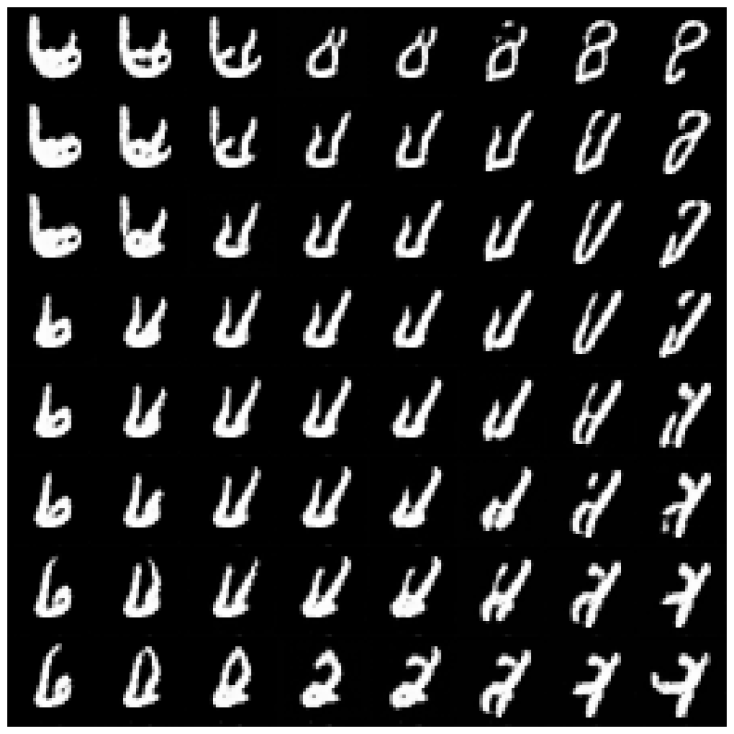

In [80]:
# === 2D сетка интерполяций между 4 угловыми точками ===
z_tl = torch.randn(1, 1, 28, 28, device=device)
z_tr = torch.randn(1, 1, 28, 28, device=device)
z_bl = torch.randn(1, 1, 28, 28, device=device)
z_br = torch.randn(1, 1, 28, 28, device=device)

grid_size = 8
lambdas_grid = np.linspace(0, 1, grid_size)

z_grid = []
for ly in lambdas_grid:
    for lx in lambdas_grid:
        z_top    = slerp(z_tl, z_tr, lx)
        z_bottom = slerp(z_bl, z_br, lx)
        z_point  = slerp(z_top, z_bottom, ly)
        z_grid.append(z_point)

z_grid = torch.cat(z_grid, dim=0).to(device)

samples_grid = ddim_from_z(model, schedule, z_grid, n_steps=50)
samples_grid = (samples_grid.cpu() + 1) / 2

# Собираем одну большую картинку вручную
canvas = np.zeros((grid_size * 28, grid_size * 28))
for row in range(grid_size):
    for col in range(grid_size):
        idx = row * grid_size + col
        canvas[row*28:(row+1)*28, col*28:(col+1)*28] = samples_grid[idx, 0].numpy()

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(canvas, cmap='gray', vmin=0, vmax=1)
ax.axis('off')
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

# Диффузионные модели в индустрии

## Latent Diffusion и Stable Diffusion

### Проблема: диффузия в пиксельном пространстве

Для изображения $512 \times 512 \times 3$ U-Net работает с тензорами размерности $\sim\!800\,000$ — на каждом из $T$ шагов. Это колоссальные вычислительные затраты.

### Идея Latent Diffusion (Rombach et al., 2022)

Проведём диффузию **в латентном пространстве VAE**:

1. **VAE-энкодер** $E$: сжимает $x \in \mathbb{R}^{H \times W \times 3}$ в латент $z = E(x) \in \mathbb{R}^{h \times w \times c}$, где $h = H/8$, $w = W/8$, $c = 4$. Сжатие в $\sim\!48$ раз.
2. **Диффузия в $\mathcal{Z}$**: forward/reverse процесс работает с компактными латентами
3. **VAE-декодер** $D$: $\hat{x} = D(z_0)$ из расшумлённого латента

### Conditioning: текст $\to$ изображение

Текст $c$ кодируется текстовым энкодером (CLIP) в последовательность эмбеддингов $\tau_\theta(c) \in \mathbb{R}^{L \times d_{\text{text}}}$.

В каждом attention-блоке U-Net:
- **Query** — из текущих активаций U-Net (визуальные фичи)
- **Key, Value** — из текстовых эмбеддингов

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

### Classifier-Free Guidance

При инференсе:

$$\tilde\varepsilon_\theta(z_t, t, c) = \varepsilon_\theta(z_t, t, \varnothing) + w \cdot \left[\varepsilon_\theta(z_t, t, c) - \varepsilon_\theta(z_t, t, \varnothing)\right]$$

где $w > 1$ — **guidance scale** (типично 7-15). Чем больше $w$, тем сильнее изображение «следует» тексту.

In [ ]:
# === Pipeline diagram (Stable Diffusion) ===
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(16, 5))

blocks = [
    (0.02, 0.3, 0.12, 0.4, 'Text\n"a cat\nwearing\na hat"', '#FFD700'),
    (0.16, 0.3, 0.12, 0.4, 'CLIP\nText\nEncoder', '#87CEEB'),
    (0.35, 0.1, 0.12, 0.8, 'U-Net\n(latent\nspace)\n\ncross-attn\nwith text\n\nT steps', '#98FB98'),
    (0.55, 0.3, 0.12, 0.4, 'Latent\n$z_0$', '#DDA0DD'),
    (0.72, 0.3, 0.12, 0.4, 'VAE\nDecoder', '#FFA07A'),
    (0.88, 0.3, 0.1, 0.4, 'Image\n512x512', '#FF6347'),
]

for x, y, w, h, text, color in blocks:
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.01",
                                     facecolor=color, edgecolor='black', lw=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=9, fontweight='bold')

arrow_style = dict(arrowstyle='->', lw=2, color='black')
for x1, x2, y in [(0.14, 0.16, 0.5), (0.28, 0.35, 0.5), (0.47, 0.55, 0.5),
                   (0.67, 0.72, 0.5), (0.84, 0.88, 0.5)]:
    ax.annotate('', xy=(x2, y), xytext=(x1, y), arrowprops=arrow_style)

ax.text(0.41, 0.95, '$z_T \\sim \\mathcal{N}(0, I)$', ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
ax.annotate('', xy=(0.41, 0.9), xytext=(0.41, 0.92), arrowprops=arrow_style)

ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.05, 1.05)
ax.set_aspect('auto'); ax.axis('off')
ax.set_title('Stable Diffusion Pipeline (Latent Diffusion Model)', fontsize=14, pad=20)
plt.tight_layout(); plt.show()

## 4.2 CLIP: связь текста и изображений

### Что такое CLIP

**CLIP** (Contrastive Language-Image Pre-training, Radford et al., 2021) — модель, обученная на ~400 млн пар (текст, изображение) из интернета.

Архитектура:
- **Image Encoder** $f_I(x)$: ViT или ResNet $\to \mathbb{R}^d$
- **Text Encoder** $f_T(c)$: Transformer $\to \mathbb{R}^d$

### Contrastive Loss

Для батча из $N$ пар $(x_i, c_i)$:

$$s_{ij} = \frac{f_I(x_i)^T f_T(c_j)}{\|f_I(x_i)\| \cdot \|f_T(c_j)\|}$$

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\left[\log\frac{\exp(s_{ii}/\tau)}{\sum_j \exp(s_{ij}/\tau)} + \log\frac{\exp(s_{ii}/\tau)}{\sum_j \exp(s_{ji}/\tau)}\right]$$

В Stable Diffusion CLIP text encoder кодирует промпты, подаваемые через cross-attention в U-Net.

In [ ]:
# === Иллюстрация контрастивного обучения CLIP ===
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
N = 6  # batch size

# Simulate similarity matrix
similarity = np.random.randn(N, N) * 0.3
# Make diagonal (matching pairs) high
for i in range(N):
    similarity[i, i] = 2.0 + np.random.rand() * 0.5

# Apply softmax temperature
tau = 0.07
exp_sim = np.exp(similarity / tau)
probs = exp_sim / exp_sim.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Raw similarities
im0 = axes[0].imshow(similarity, cmap='RdBu_r', vmin=-1, vmax=3)
axes[0].set_title('Cosine similarity $s_{ij}$', fontsize=12)
axes[0].set_xlabel('Text'); axes[0].set_ylabel('Image')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Softmax probabilities
im1 = axes[1].imshow(probs, cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('After softmax (row-wise)', fontsize=12)
axes[1].set_xlabel('Text'); axes[1].set_ylabel('Image')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# Target: identity matrix
target = np.eye(N)
im2 = axes[2].imshow(target, cmap='Blues', vmin=0, vmax=1)
axes[2].set_title('Target: matching pairs', fontsize=12)
axes[2].set_xlabel('Text'); axes[2].set_ylabel('Image')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.set_xticks(range(N)); ax.set_yticks(range(N))

plt.suptitle('CLIP: contrastive learning on (image, text) pairs', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

CLIP обучается так, чтобы правильные пары (изображение $i$, текст $i$) имели максимальное сходство (диагональ матрицы), а неправильные пары — минимальное. После обучения текстовый и визуальный энкодеры «понимают» одну семантику: эмбеддинг текста «кот» оказывается близок к эмбеддингам фотографий котов.

Именно это свойство делает CLIP идеальным мостом между текстовыми промптами и диффузионной генерацией.

## 4.3 Эволюция DALL-E

### DALL-E 1 (Ramesh et al., 2021)

1. **Дискретный VAE (dVAE):** изображение кодируется в $32 \times 32$ дискретных токенов
2. **Авторегрессия:** GPT-подобная модель (12 млрд параметров) генерирует токены
3. **CLIP** для reranking сгенерированных вариантов

### DALL-E 2 (Ramesh et al., 2022)

Переход к **диффузионному** подходу:
1. **CLIP:** текст и изображение в общее эмбеддинг-пространство
2. **Prior:** диффузия переводит текстовый CLIP-эмбеддинг в изображенческий
3. **Decoder (unCLIP):** вторая диффузия генерирует изображение по CLIP-эмбеддингу

### DALL-E 3 (Betker et al., 2023)

1. Обучен специальный **captioner** для подробных описаний изображений
2. Модель обучена на парах (подробное описание, изображение) — критически улучшает следование промпту
3. T5 для текстового кодирования + диффузия в латентном пространстве

Эволюция DALL-E показывает путь от авторегрессии к диффузии, и значимость качества данных.

## 4.4 Современное состояние и тренды

### Ускорение инференса

**Distillation** — обучить «ученика» (меньше шагов) имитировать «учителя». Progressive distillation: итеративно сокращают число шагов вдвое.

**Consistency Models** (Song et al., 2023) — модель напрямую отображает любую точку траектории ODE в $x_0$. Генерация за 1-2 шага.

**Rectified Flow / Flow Matching** (Lipman et al., 2022) — ODE с прямолинейными траекториями, мало шагов без дополнительных ухищрений.

### Генерация видео

**Sora** (OpenAI, 2024), **Runway Gen-3**, **Stable Video Diffusion** — пространственно-временной U-Net или DiT (Diffusion Transformer), temporal attention для согласованности кадров.

### За пределами изображений

- **Аудио:** AudioLDM, MusicGen
- **3D:** DreamFusion, Magic3D — генерация 3D через score distillation
- **Молекулы:** Equivariant diffusion для дизайна белков
- **Текст:** Diffusion-LM, MDLM — дискретная диффузия (активная область исследований)

### Полный пайплайн генерации Stable Diffusion

Соединив все компоненты, получаем следующий алгоритм text-to-image генерации:

```
Вход: текстовый промпт c, guidance scale w, число шагов S

1. Кодировать текст: emb = CLIP_text_encoder(c)
2. Семплировать начальный латент: z_T ~ N(0, I)   (размер h x w x 4)
3. Для каждого шага s = S, S-1, ..., 1:
    a. Предсказать шум дважды:
       eps_cond   = UNet(z_s, s, emb)        # условное предсказание
       eps_uncond = UNet(z_s, s, empty_emb)   # безусловное предсказание
    b. Classifier-free guidance:
       eps_guided = eps_uncond + w * (eps_cond - eps_uncond)
    c. DDIM/DDPM шаг: z_{s-1} = denoise_step(z_s, eps_guided)
4. Декодировать латент: image = VAE_decoder(z_0)
```

Обратите внимание: на каждом шаге денойзинга U-Net вызывается **дважды** (условно и безусловно). Это основная причина, почему classifier-free guidance удваивает время инференса.

# Заключение

На этой лекции мы прошли путь от VAE к диффузионным моделям, показав, что диффузия — это **естественное обобщение** латентного вероятностного моделирования:

1. **Дискретное время:** диффузия = VAE с цепочкой латентных переменных. ELBO раскладывается на сумму KL-дивергенций, каждая из которых сводится к задаче денойзинга.

2. **Параметризация:** $\varepsilon$-параметризация делает задачу регрессии стационарной по времени.

3. **Непрерывное время:** при $T \to \infty$ получаем SDE/ODE формулировку. Score function напрямую связана с $\varepsilon$-параметризацией.

4. **Практика:** DDIM для ускорения, Latent Diffusion + CLIP для text-to-image, эволюция от DALL-E 1 к DALL-E 3.

Диффузионные модели совмещают **высокое качество** с **хорошим покрытием мод** и **теоретической обоснованностью**, что сделало их стандартом в генеративном AI.

# Ресурсы

### Основные статьи

- **[DDPM]** Ho, Jain, Abbeel. *Denoising Diffusion Probabilistic Models* (NeurIPS 2020) — https://arxiv.org/abs/2006.11239
- **[Score SDE]** Song et al. *Score-Based Generative Modeling through SDE* (ICLR 2021) — https://arxiv.org/abs/2011.13456
- **[DDIM]** Song, Meng, Ermon. *Denoising Diffusion Implicit Models* (ICLR 2021) — https://arxiv.org/abs/2010.02502
- **[Latent Diffusion]** Rombach et al. *High-Resolution Image Synthesis with Latent Diffusion Models* (CVPR 2022) — https://arxiv.org/abs/2112.10752
- **[CLIP]** Radford et al. *Learning Transferable Visual Models From Natural Language Supervision* (ICML 2021) — https://arxiv.org/abs/2103.00020
- **[DALL-E 2]** Ramesh et al. *Hierarchical Text-Conditional Image Generation with CLIP Latents* — https://arxiv.org/abs/2204.06125
- **[Classifier-Free Guidance]** Ho, Salimans. *Classifier-Free Diffusion Guidance* — https://arxiv.org/abs/2207.12598

### Туториалы и обзоры

- Lilian Weng. *What are Diffusion Models?* — https://lilianweng.github.io/posts/2021-07-11-diffusion-models/
- Yang Song. *Generative Modeling by Estimating Gradients of the Data Distribution* — https://yang-song.net/blog/2021/score/
- Calvin Luo. *Understanding Diffusion Models: A Unified Perspective* — https://arxiv.org/abs/2208.11970